<h1> Neural Networks Using Tensor Flow </h1>

<h3> By: Ryan Moore </h3>

<H3> Introduction </H3>

The objective of this analysis is to build a neural network that is capable of identifying handwritten digits.  The model is trained and tested on a a dataset in TensorFlow that contains images of handwritten digits call MNIST dataset. 

The problem of handwritten digit recognition is a computer vision task using machine learning.  This can be used for processing bank checks.  By teaching a computer to correctly identify handwritten digits, a bank would be able to determine the amount the check was made out for, the date, the check number, the account number, and the routing number.

The MNIST dataset contains a large collection of grayscale images of handwritten digits that can be used to train and test a neural network on. Using a neural network for this analysis is the right machine learning model because the neural network can automatically learn most of the relevant features without needing to specify different features like other machine models would require. 

In [ ]:
import tensorflow as tf
import seaborn as sns
import keras
import numpy as np 
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score

In [22]:
#Load the dataset
(ds_train, ds_test), ds_info = tfds.load(
    'mnist',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

In [23]:
#Print the number of training examples
print(f"Number of training examples: {ds_info.splits['train'].num_examples}")

# Print the number of test examples
print(f"Number of test examples: {ds_info.splits['test'].num_examples}")

# Print the feature names and their properties
print("Features:")
print(ds_info.features)

Number of training examples: 60000
Number of test examples: 10000
Features:
FeaturesDict({
    'image': Image(shape=(28, 28, 1), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
})


<H3> Analysis </H3>

<h4> Data </h4>
The dataset contains 70,000 images. 
The images are 28 pixels by 28 pixels and have one color.
The images are stored as unsigned 8-bit integers. 
The labels are stored as 64-bit integers.
There are 10 distinct classes in the dataset which correspond to the digits 0 through 9. 

2025-08-25 16:30:32.270333: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-08-25 16:30:32.271116: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


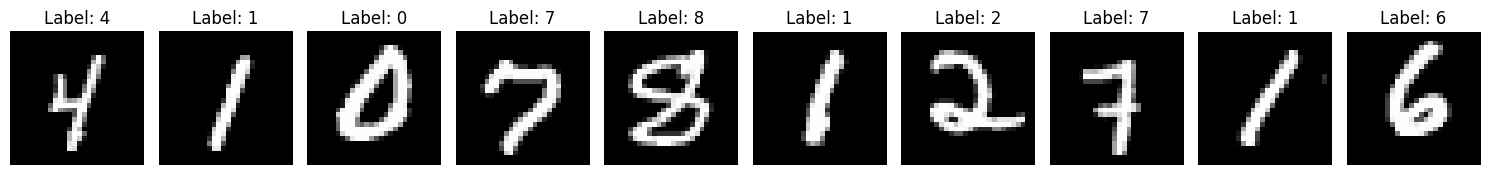

In [24]:
#Visualize the first 10 images to see the dataset
items_to_plot = list(ds_train.take(10))

# Create the figure and axes objects
fig, axes = plt.subplots(1, 10, figsize=(15, 2))

#For loop to covert into Numpy Arrays for plotting
for i, (image, label) in enumerate(items_to_plot):
    image = image.numpy()
    label = label.numpy()
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Label: {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()



<H4> Exploratory Analysis </H4>
Images are handwritten digits that are a bit blurry and low resolution. 

The images are in a black box and written with white ink. 

The handwriting has different styles such as the 7. One has a line through it while the other does not. 

<H3> Data Pipeline </H3>

<H4> Preprocessing </H4>

In [25]:
#Preprocessing - Normalization of the the pixel values to (0-255) tf.float 32 (0-1) so that the model can train more effectively. 
def normalize_img(image, label):
  return tf.cast(image, tf.float32) / 255., label

'''Cache the dataset so that the results of the map operation are stored. 
Shuffle the images so the model cannot learn the order of the images
Batched the images into batches of 128 images. 
Prefetch so that the model prepares the next batch while the model is still being trained on the current batch'''

ds_train = ds_train.map(
    normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_train = ds_train.cache()
ds_train = ds_train.shuffle(ds_info.splits['train'].num_examples)
ds_train = ds_train.batch(128)
ds_train = ds_train.prefetch(tf.data.AUTOTUNE)


In [26]:
#Set up the test dataset the same way as the train dataset
ds_test = ds_test.map(
    normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.batch(128)
ds_test = ds_test.cache()
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)

<H4> Algorithm Intuition & Model Fitting </H4>

In [27]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(10)
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()],
)

model.fit(
    ds_train,
    epochs=6,
    validation_data=ds_test,
)

Epoch 1/6


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3596 - sparse_categorical_accuracy: 0.9002 - val_loss: 0.1928 - val_sparse_categorical_accuracy: 0.9438
Epoch 2/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1680 - sparse_categorical_accuracy: 0.9518 - val_loss: 0.1368 - val_sparse_categorical_accuracy: 0.9578
Epoch 3/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1203 - sparse_categorical_accuracy: 0.9658 - val_loss: 0.1125 - val_sparse_categorical_accuracy: 0.9644
Epoch 4/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0928 - sparse_categorical_accuracy: 0.9740 - val_loss: 0.0936 - val_sparse_categorical_accuracy: 0.9715
Epoch 5/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0750 - sparse_categorical_accuracy: 0.9786 - val_loss: 0.0884 - val_sparse_categorical_accuracy: 0.9743
Epoch 6/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0626 - sparse_categorical_accuracy: 0.9819 - val_loss: 0.0811 - val_sparse_categorical_accuracy: 0.9749


2025-08-25 16:30:39.722040: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


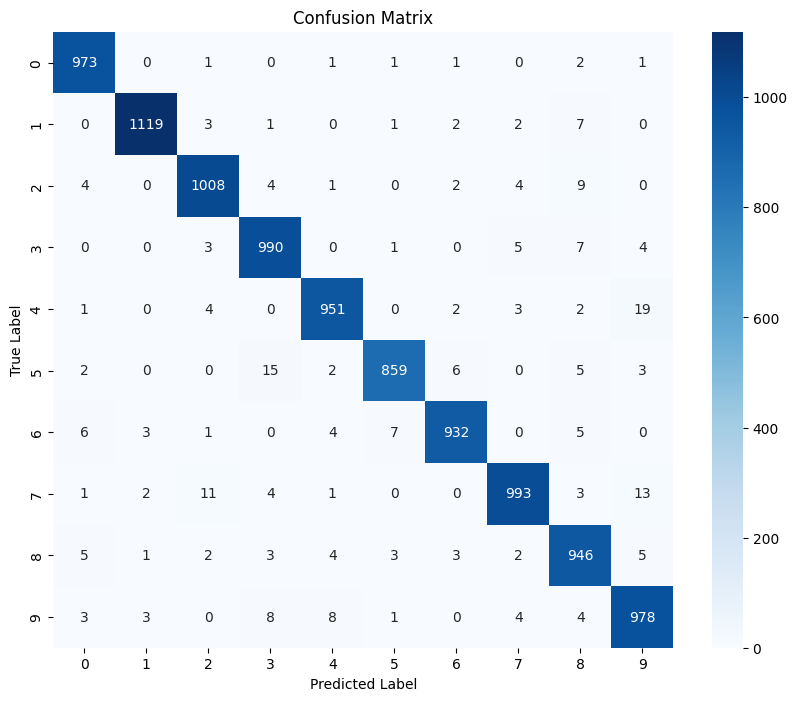

In [ ]:
#Confusion Matrix

true_labels = []
predicted_labels = []
for images, labels in ds_test:
    predictions = model(images)
    predicted_labels.extend(tf.argmax(predictions, axis=1).numpy())
    true_labels.extend(labels.numpy())

# Create the confusion matrix tensor
cm = tf.math.confusion_matrix(labels=true_labels, predictions=predicted_labels)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [29]:
# Print the full classification report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels))

# Print the overall accuracy
accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Overall Accuracy: {accuracy:.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.98      0.97      1010
           4       0.98      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.97      0.98       958
           7       0.98      0.97      0.97      1028
           8       0.96      0.97      0.96       974
           9       0.96      0.97      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.98      0.97      0.97     10000

Overall Accuracy: 0.9749


<H3> Results </H3>

The overall performance of the model was a 97.49% accuracy.  The model did misinterpret some numbers with similar features such as a 9 for a 4 but these mistakes were relatively small compared to correct number of predictions. Every number had an accuracy of 96% or above, recall of 96% or above, and f1-score of 96% or above.

